# Showcase — real data, real tables, real charts

This notebook is **committed with its outputs**: what you see on GitHub is what the pipeline produces.
Data: vendored `data/*.csv` (offline). Library calls are the same à la carte functions from `library_usage.ipynb`.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from ml_boilerplate.config import Config, ModelConfig
from ml_boilerplate.crossval import run_cv
from ml_boilerplate.data import load_data
from ml_boilerplate.eda import profile_dataframe
from ml_boilerplate.evaluation import evaluate_on_test
from ml_boilerplate.io import read_table
from ml_boilerplate.model import build_model
from ml_boilerplate.monitor import check_drift
from ml_boilerplate.distributions import data_distributions
from ml_boilerplate.tasks import get_task
from ml_boilerplate.validation import split_train_val_test

DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents]
               if (p / 'data' / 'mpg.csv').exists()), Path('data'))
plt.style.use('seaborn-v0_8-whitegrid')
print('data dir:', DATA.resolve())

data dir: /home/rajindersingh/personal_work/ml_boiler_plate/data


## 1. Tables — first look at Penguins (344 rows, 3 species, real missing values)

In [2]:
pg = read_table(str(DATA / 'penguins.csv'))
display(pg.head())
prof = profile_dataframe(pg)
display(pd.DataFrame(prof['missing']).T.query('count > 0'))
display(pg.describe().round(2))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


,count,pct
bill_length_mm,2.0,0.58
bill_depth_mm,2.0,0.58
flipper_length_mm,2.0,0.58
body_mass_g,2.0,0.58
sex,11.0,3.20


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


## 2. Charts — distributions and a species scatter

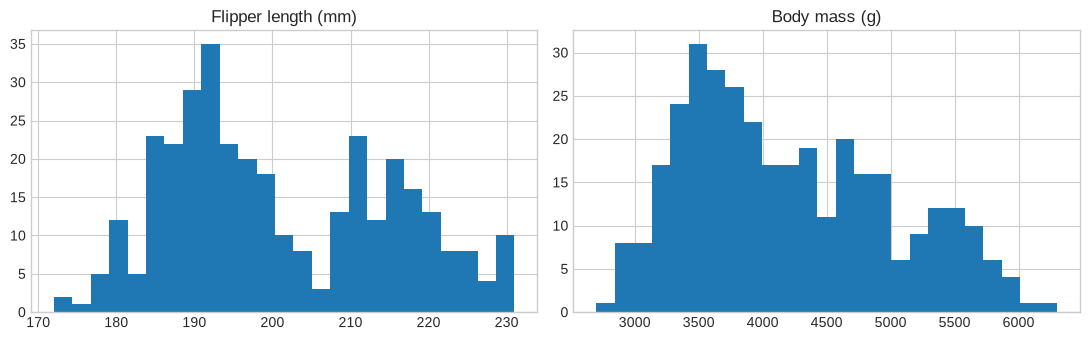

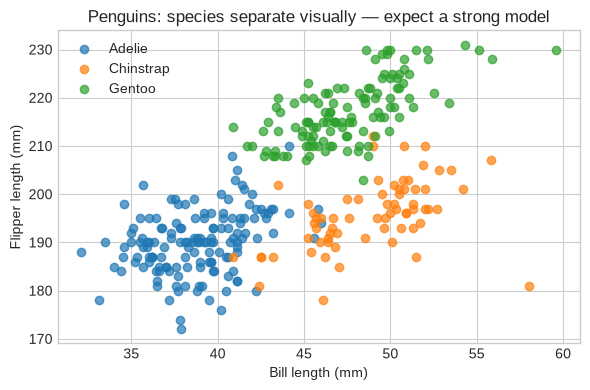

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
pg['flipper_length_mm'].hist(bins=25, ax=axes[0])
axes[0].set_title('Flipper length (mm)')
pg['body_mass_g'].hist(bins=25, ax=axes[1])
axes[1].set_title('Body mass (g)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for sp, grp in pg.dropna().groupby('species'):
    ax.scatter(grp['bill_length_mm'], grp['flipper_length_mm'], label=sp, alpha=0.7)
ax.set_xlabel('Bill length (mm)'); ax.set_ylabel('Flipper length (mm)')
ax.set_title('Penguins: species separate visually — expect a strong model')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Train penguins → metrics table, confusion matrix, importances

,score
accuracy,1.0
precision,1.0
recall,1.0
f1,1.0


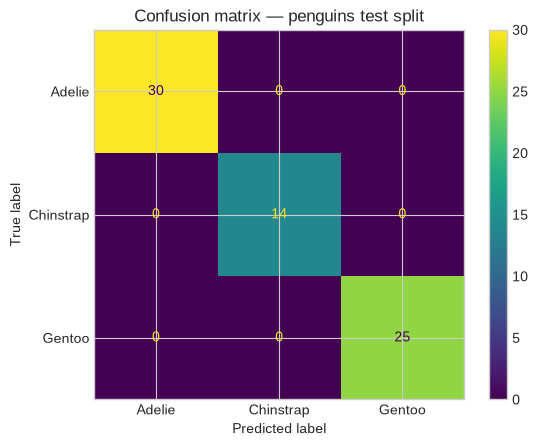

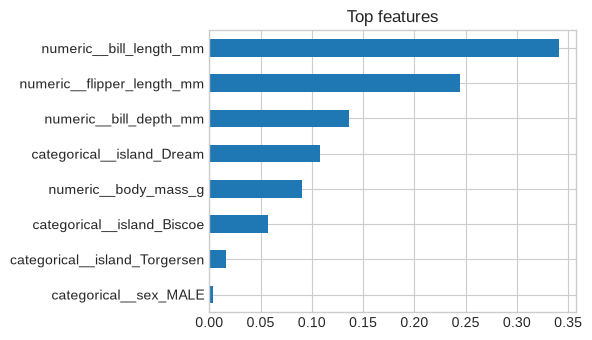

In [4]:
cfg = Config(task='classification')
X = pg.drop(columns=['species']); y = pg['species']
Xtr, _, Xte, ytr, _, yte = split_train_val_test(X, y, cfg, 'classification')
task = get_task('classification')
pipe = Pipeline([('preprocess', task.build_preprocessor(Xtr, cfg)),
                   ('model', build_model(ModelConfig(type='random_forest',
                                   params={'n_estimators': 100}), task.model_registry()))])
pipe.fit(Xtr, ytr)
pred = pipe.predict(Xte)
gate = evaluate_on_test(yte.to_numpy(), pred, None, 'classification', {})
display(pd.Series(gate['metrics']).round(4).to_frame('score'))

ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=pipe.classes_)
plt.title('Confusion matrix — penguins test split'); plt.show()

names = pipe.named_steps['preprocess'].get_feature_names_out()
imp = pd.Series(pipe.named_steps['model'].feature_importances_, index=names)
imp.sort_values().tail(8).plot(kind='barh', figsize=(6, 3.5))
plt.title('Top features'); plt.tight_layout(); plt.show()

## 4. Regression tables — MPG cross-validation per fold

In [5]:
mpg = read_table(str(DATA / 'mpg.csv'))
cfg2 = Config(task='regression')
cfg2.cross_validation.folds = 3
X2 = mpg.drop(columns=['mpg']); y2 = mpg['mpg']
cfg2.model = ModelConfig(type='random_forest', params={'n_estimators': 50})
cv = run_cv(X2, y2, cfg2, 'regression')
display(pd.DataFrame(cv['per_fold']).round(3))
display(pd.DataFrame({k: v for k, v in cv['aggregate'].items()}).round(3))

,mae,rmse,r2,mape,smape
0,1.772,2.367,0.905,7.659,7.525
1,2.117,3.136,0.840,9.220,8.973
2,2.155,3.155,0.838,9.049,9.037


,mae,rmse,r2,mape,smape
mean,2.014,2.886,0.861,8.643,8.512
std,0.172,0.367,0.031,0.699,0.698


## 5. Timeseries chart — daily births forecast vs actual

,score
mae,6.759
rmse,8.263
r2,-0.609
mape,17.463
smape,15.465


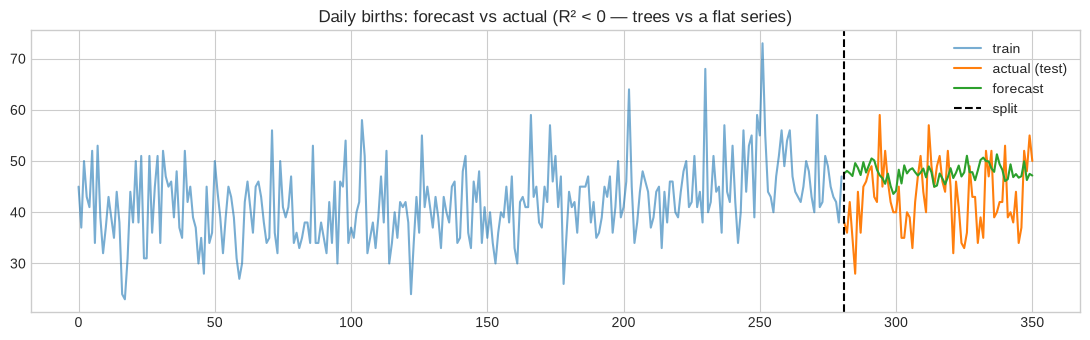

In [6]:
cfg3 = Config(task='timeseries')
cfg3.data.date_column = 'Date'; cfg3.data.target_column = 'Births'
b = read_table(str(DATA / 'daily-female-births.csv'))
t3 = get_task('timeseries')
Xtr3, Xte3, ytr3, yte3 = t3.split(b, cfg3)
pipe3 = Pipeline([('preprocess', t3.build_preprocessor(Xtr3, cfg3)),
                    ('model', build_model(ModelConfig(type='random_forest',
                                    params={'n_estimators': 100}), t3.model_registry()))])
pipe3.fit(Xtr3, ytr3)
pred3 = pipe3.predict(Xte3)
m3 = evaluate_on_test(yte3.to_numpy(), pred3, None, 'timeseries', {})
display(pd.Series(m3['metrics']).round(3).to_frame('score'))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ytr3.to_numpy(), label='train', alpha=0.6)
ax.plot(range(len(ytr3), len(ytr3) + len(yte3)), yte3.to_numpy(), label='actual (test)')
ax.plot(range(len(ytr3), len(ytr3) + len(yte3)), pred3, label='forecast')
ax.axvline(len(ytr3), color='k', linestyle='--', label='split')
ax.set_title('Daily births: forecast vs actual (R² < 0 — trees vs a flat series)')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Drift table — PSI per column, clean vs shifted batch

In [7]:
profile = data_distributions(mpg, 'mpg')
shifted = mpg.copy(); shifted['weight'] = shifted['weight'] * 3
drift_tbl = pd.DataFrame({
    'psi_clean': check_drift(profile, mpg)['psi'],
    'psi_shifted_weight_x3': check_drift(profile, shifted)['psi'],
}).round(4)
display(drift_tbl)
print('PSI > 0.25 = drifted. Only weight moves — exactly as injected.')

,psi_clean,psi_shifted_weight_x3
mpg,0.0,0.0000
cylinders,0.0,0.0000
displacement,0.0,0.0000
horsepower,0.0,0.0000
weight,0.0,12.4221
acceleration,0.0,0.0000
model_year,0.0,0.0000


PSI > 0.25 = drifted. Only weight moves — exactly as injected.
